# LSTM Forecasting for ISPU (PM10 & PM2.5)

This notebook uses pre-engineered features from `../feature/final_feature.csv`.

In [51]:
# 1. Imports & Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import warnings
import os

warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)
plt.style.use('ggplot')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [52]:
# 2. Load Pre-Engineered Features
DATA_PATH = '../feature/final_feature.csv'

df = pd.read_csv(DATA_PATH)
df['tanggal'] = pd.to_datetime(df['tanggal'])
df = df.set_index('tanggal')

print(f"Loaded: {df.shape}")
df.head()

Loaded: (15412, 58)


,stasiun,pm10,pm25,so2,co,o3,no2,max,critical_parameter,target_kategori,...,quarter,month_feat,year_feat,dayofyear,lag_1,lag_7,lag_30,rolling_mean_7,rolling_std_7,rolling_mean_30
tanggal,,,,,,,,,,,,,,,,,,,,,
2010-01-01,DKI1,60.0,65.496864,4.0,73.0,27.0,14.0,73.0,CO,SEDANG,...,1.0,1.0,2010.0,1.0,NaN,NaN,NaN,60.000000,NaN,60.000000
2010-01-02,DKI1,32.0,51.534592,2.0,16.0,33.0,9.0,33.0,O3,BAIK,...,1.0,1.0,2010.0,2.0,60.0,NaN,NaN,46.000000,19.798990,46.000000
2010-01-03,DKI1,27.0,43.427841,2.0,19.0,20.0,9.0,27.0,PM10,BAIK,...,1.0,1.0,2010.0,3.0,32.0,NaN,NaN,39.666667,17.785762,39.666667
2010-01-04,DKI1,22.0,35.773327,2.0,16.0,15.0,6.0,22.0,PM10,BAIK,...,1.0,1.0,2010.0,4.0,27.0,NaN,NaN,35.250000,16.997549,35.250000
2010-01-05,DKI1,25.0,37.706676,2.0,17.0,15.0,8.0,25.0,PM10,BAIK,...,1.0,1.0,2010.0,5.0,22.0,NaN,NaN,33.200000,15.417522,33.200000


In [53]:
# 3. Use ALL stations for training
TARGET = 'target_kategori'
station_df = df.dropna(subset=[TARGET]).copy()
station_df = station_df.dropna(thresh=int(len(station_df.columns) * 0.7), axis=0)
print(f"Data shape for ALL stations: {station_df.shape}")

Data shape for ALL stations: (15083, 58)


In [54]:
# 4. Prepare Data for LSTM Classification
from sklearn.preprocessing import LabelEncoder

# Map to 3 categories
def map_to_3_categories(cat):
    if cat in ['SANGAT TIDAK SEHAT', 'BERBAHAYA']: 
        return 'TIDAK SEHAT'
    return cat

station_df['target_mapped'] = station_df[TARGET].apply(map_to_3_categories)

# Encode target categories
label_encoder = LabelEncoder()
station_df['target_encoded'] = label_encoder.fit_transform(station_df['target_mapped'])
print(f"Target classes: {label_encoder.classes_}")
print(f"Class distribution:\n{station_df['target_mapped'].value_counts()}")

# Select numeric features (exclude target columns)
features = [c for c in station_df.select_dtypes(include=[np.number]).columns.tolist() 
            if c not in ['target_idx', 'target_encoded']]
print(f"\nFeatures: {len(features)}")

# Fill any remaining NaN
data = station_df[features].fillna(method="ffill").fillna(method="bfill").fillna(0)
target_data = station_df['target_encoded'].values
print(f"Data shape: {data.shape}, Target shape: {target_data.shape}")

Target classes: ['BAIK' 'SEDANG' 'TIDAK SEHAT']
Class distribution:
target_mapped
SEDANG         10324
TIDAK SEHAT     2486
BAIK            2273
Name: count, dtype: int64

Features: 53
Data shape: (15083, 53), Target shape: (15083,)


In [55]:
# 5. Scaling
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)
print(f"Scaled data shape: {scaled_data.shape}")

Scaled data shape: (15083, 53)


In [56]:
# 6. Sequence Creation for Classification
SEQ_LENGTH = 30

X_seq = []
y_seq = []

for i in range(len(scaled_data) - SEQ_LENGTH):
    X_seq.append(scaled_data[i:i+SEQ_LENGTH])
    y_seq.append(target_data[i+SEQ_LENGTH])  # Use target category

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print(f"X shape: {X_seq.shape}")
print(f"y shape: {y_seq.shape}")
print(f"Target distribution in sequences: {np.bincount(y_seq)}")

X shape: (15053, 30, 53)
y shape: (15053,)
Target distribution in sequences: [ 2255 10312  2486]


In [57]:
# 7. Train/Val Split
split = int(0.8 * len(X_seq))

X_train, X_val = X_seq[:split], X_seq[split:]
y_train, y_val = y_seq[:split], y_seq[split:]

print(f"Train: {X_train.shape}, Val: {X_val.shape}")
print(f"Train target dist: {np.bincount(y_train)}")
print(f"Val target dist: {np.bincount(y_val)}")

Train: (12042, 30, 53), Val: (3011, 30, 53)
Train target dist: [1736 8393 1913]
Val target dist: [ 519 1919  573]


In [58]:
# 8. Create DataLoaders for Classification
BATCH_SIZE = 32

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)  # Long for classification
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

train_dataset = torch.utils.data.TensorDataset(X_train_t, y_train_t)
val_dataset = torch.utils.data.TensorDataset(X_val_t, y_val_t)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Train batches: 377, Val batches: 95


In [59]:
# 9. LSTM Classification Model Definition
class AirQualityLSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.2):
        super(AirQualityLSTMClassifier, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])  # Take last timestep output
        return out

INPUT_SIZE = X_train.shape[2]
NUM_CLASSES = len(label_encoder.classes_)  # 3 classes
model = AirQualityLSTMClassifier(input_size=INPUT_SIZE, hidden_size=64, num_layers=2, num_classes=NUM_CLASSES, dropout=0.3)
model = model.to(device)
print(model)
print(f"\nModel parameters: {sum(p.numel() for p in model.parameters())}")

AirQualityLSTMClassifier(
  (lstm): LSTM(53, 64, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=64, out_features=3, bias=True)
)

Model parameters: 63939


In [60]:
# 10. Training with CrossEntropyLoss
from sklearn.metrics import f1_score

EPOCHS = 50
PATIENCE = 10
LR = 0.001

criterion = nn.CrossEntropyLoss()  # For classification
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

best_val_loss = float('inf')
best_val_f1 = 0.0
patience_counter = 0
train_losses = []
val_losses = []
val_f1_scores = []
best_model_state = None

for epoch in range(EPOCHS):
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        batch_losses.append(loss.item())
    
    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)
    
    # Validation
    model.eval()
    val_batch_losses = []
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            output = model(X_batch)
            loss = criterion(output, y_batch)
            val_batch_losses.append(loss.item())
            
            # Get predictions
            preds = torch.argmax(output, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(y_batch.cpu().numpy())
    
    val_loss = np.mean(val_batch_losses)
    val_losses.append(val_loss)
    
    # Calculate F1 score
    val_f1 = f1_score(all_targets, all_preds, average='macro')
    val_f1_scores.append(val_f1)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}")
    
    if np.isnan(train_loss) or np.isnan(val_loss):
        print("NaN loss detected. Stopping.")
        break
    
    # Save best model based on F1 score
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict()
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"\nLoaded best model with Val Loss: {best_val_loss:.4f} | Val F1: {best_val_f1:.4f}")

Epoch 5/50 | Train Loss: 0.5488 | Val Loss: 0.6546 | Val F1: 0.5638
Epoch 10/50 | Train Loss: 0.5260 | Val Loss: 0.6152 | Val F1: 0.6364
Epoch 15/50 | Train Loss: 0.5092 | Val Loss: 0.6924 | Val F1: 0.6230
Epoch 20/50 | Train Loss: 0.4952 | Val Loss: 0.6263 | Val F1: 0.6606
Epoch 25/50 | Train Loss: 0.4848 | Val Loss: 0.6691 | Val F1: 0.6234
Early stopping triggered at epoch 28

Loaded best model with Val Loss: 0.6316 | Val F1: 0.6775


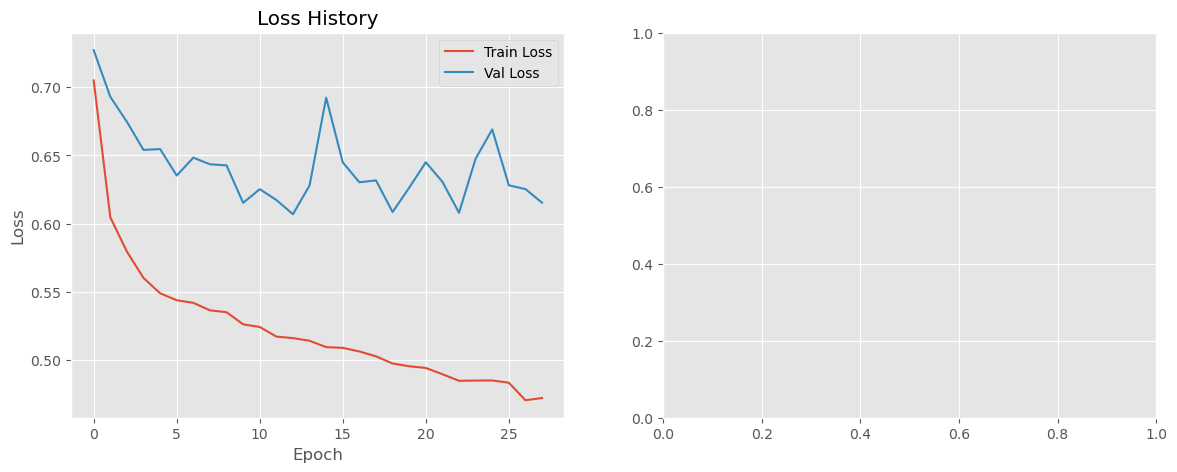

Text(0.5, 25.0, 'Epoch')

<Figure size 640x480 with 0 Axes>

In [61]:
# 11. Plot Training History
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.legend()
ax1.set_title('Loss History')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')

ax1.grid(True)
plt.show()

plt.tight_layout()

ax2.plot(val_f1_scores, label='Val F1-Macro', color='green')

ax2.legend()
ax2.grid(True)

ax2.set_title('Validation F1 Score')
ax2.set_ylabel('F1 Score')
ax2.set_xlabel('Epoch')

In [62]:
# 12. Sample Predictions
model.eval()
with torch.no_grad():
    sample_X = X_val_t[-10:].to(device)
    sample_output = model(sample_X)
    sample_pred = torch.argmax(sample_output, dim=1).cpu().numpy()
    sample_true = y_val_t[-10:].numpy()

print("Last 10 Predictions:")
for i, (pred, true) in enumerate(zip(sample_pred, sample_true)):
    pred_cat = label_encoder.inverse_transform([pred])[0]
    true_cat = label_encoder.inverse_transform([true])[0]
    print(f"{i+1}. Pred: {pred_cat:15} | True: {true_cat:15} | {'✓' if pred==true else '✗'}")

Last 10 Predictions:
1. Pred: SEDANG          | True: SEDANG          | ✓
2. Pred: SEDANG          | True: TIDAK SEHAT     | ✗
3. Pred: SEDANG          | True: SEDANG          | ✓
4. Pred: SEDANG          | True: SEDANG          | ✓
5. Pred: SEDANG          | True: TIDAK SEHAT     | ✗
6. Pred: TIDAK SEHAT     | True: TIDAK SEHAT     | ✓
7. Pred: TIDAK SEHAT     | True: SEDANG          | ✗
8. Pred: SEDANG          | True: SEDANG          | ✓
9. Pred: SEDANG          | True: SEDANG          | ✓
10. Pred: SEDANG          | True: SEDANG          | ✓


In [63]:
# 13. Generate Submission using LSTM Predictions
submission_start = pd.Timestamp('2025-09-01')
submission_end = pd.Timestamp('2025-11-30')
submission_date_range = pd.date_range(start=submission_start, end=submission_end, freq='D')
stations = sorted([s for s in df['stasiun'].unique() if pd.notna(s)])

print(f"{'='*60}\nGenerating LSTM Submission Predictions\n{'='*60}")
print(f"Period: {submission_start.date()} to {submission_end.date()}")
print(f"Total days: {len(submission_date_range)}")
print(f"Stations: {stations}")

submission_records = []
model.eval()

for station in stations:
    print(f"\n📊 Processing {station}...")
    
    station_data = df[df['stasiun'] == station].copy()
    if len(station_data) < SEQ_LENGTH:
        print(f"  ⚠️ Not enough data for {station} (need {SEQ_LENGTH} days), skipping...")
        continue
    
    # Prepare last SEQ_LENGTH days of features for this station
    station_features = station_data[features].fillna(method='ffill').fillna(method='bfill').fillna(0)
    
    if len(station_features) < SEQ_LENGTH:
        print(f"  ⚠️ Insufficient data after preprocessing, skipping...")
        continue
    
    # Get last sequence
    last_seq = station_features.iloc[-SEQ_LENGTH:].values
    last_seq_scaled = scaler.transform(last_seq)
    
    # Create tensor
    last_seq_tensor = torch.FloatTensor(last_seq_scaled).unsqueeze(0).to(device)
    
    # Predict using LSTM
    with torch.no_grad():
        output = model(last_seq_tensor)
        pred_class = torch.argmax(output, dim=1).cpu().numpy()[0]
        pred_category = label_encoder.inverse_transform([pred_class])[0]
    
    print(f"  Predicted base category: {pred_category}")
    
    # Use same prediction for all dates (simple LSTM baseline)
    for date in submission_date_range:
        submission_records.append({
            'id': f"{date.strftime('%Y-%m-%d')}_{station}", 
            'category': pred_category
        })
    
    print(f"  ✓ Generated {len(submission_date_range)} predictions")

submission_df = pd.DataFrame(submission_records)
print(f"\n{'='*60}")
print(f"Submission shape: {submission_df.shape}")
print(f"Expected shape: (455, 2)")
print(f"\nCategory distribution:\n{submission_df['category'].value_counts()}")

Generating LSTM Submission Predictions
Period: 2025-09-01 to 2025-11-30
Total days: 91
Stations: ['DKI1', 'DKI2', 'DKI3', 'DKI4', 'DKI5']

📊 Processing DKI1...
  Predicted base category: SEDANG
  ✓ Generated 91 predictions

📊 Processing DKI2...
  Predicted base category: TIDAK SEHAT
  ✓ Generated 91 predictions

📊 Processing DKI3...
  Predicted base category: SEDANG
  ✓ Generated 91 predictions

📊 Processing DKI4...
  Predicted base category: SEDANG
  ✓ Generated 91 predictions

📊 Processing DKI5...
  Predicted base category: TIDAK SEHAT
  ✓ Generated 91 predictions

Submission shape: (455, 2)
Expected shape: (455, 2)

Category distribution:
category
SEDANG         273
TIDAK SEHAT    182
Name: count, dtype: int64


Submission saved: ../predictions_lstm.csv

FINAL EVALUATION: LSTM vs Ground Truth (Sep-Nov 2025)
Matched predictions: 455 / 455

🎯 F1-Score (Macro):    0.2860
🎯 F1-Score (Weighted): 0.5922

Classification Report:
              precision    recall  f1-score   support

        BAIK       0.00      0.00      0.00        63
      SEDANG       0.85      0.63      0.72       368
 TIDAK SEHAT       0.08      0.64      0.14        22

   micro avg       0.54      0.54      0.54       453
   macro avg       0.31      0.42      0.29       453
weighted avg       0.69      0.54      0.59       453



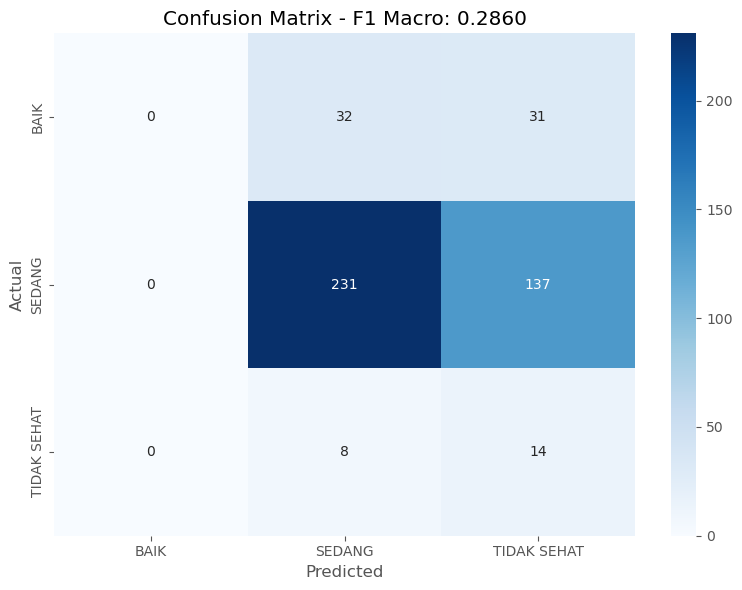

In [64]:
# 14. Evaluation vs Ground Truth
submission_df.to_csv('../predictions_lstm.csv', index=False)
print(f"Submission saved: ../predictions_lstm.csv")

try:
    gt = pd.read_csv('../dataset/data-indeks-standar-pencemar-udara-(ispu)-di-provinsi-dki-jakarta-komponen-data.csv')
except:
    gt = None

if gt is not None:
    from sklearn.metrics import f1_score, classification_report, confusion_matrix
    import seaborn as sns
    
    # Parse date from periode_data (YYYYMM format) + tanggal (day)
    gt['year'] = gt['periode_data'] // 100
    gt['month'] = gt['periode_data'] % 100
    gt['day'] = gt['tanggal']
    gt['tanggal'] = pd.to_datetime(gt[['year', 'month', 'day']], errors='coerce')
    
    # Map station names
    station_map = {'DKI1 Bunderan HI': 'DKI1', 'DKI1 Bundaran Hotel Indonesia (HI)': 'DKI1', 'DKI1 Bundaran Hotel Indonesia HI': 'DKI1', 'DKI2 Kelapa Gading': 'DKI2', 'DKI3 Jagakarsa': 'DKI3', 'DKI4 Lubang Buaya': 'DKI4', 'DKI5 Kebon Jeruk': 'DKI5', 'DKI5 Kebon Jeruk Jakarta Barat': 'DKI5'}
    gt['stasiun'] = gt['stasiun'].map(station_map).fillna(gt['stasiun'])
    gt_2025 = gt[(gt['tanggal'] >= '2025-09-01') & (gt['tanggal'] <= '2025-11-30')].copy()
    gt_2025['id'] = gt_2025['tanggal'].dt.strftime('%Y-%m-%d') + '_' + gt_2025['stasiun']
    
    def map_to_3_categories(cat):
        if cat in ['SANGAT TIDAK SEHAT', 'BERBAHAYA']: return 'TIDAK SEHAT'
        return cat
    
    # Use 'kategori' column from the CSV file
    col_name = 'target_kategori' if 'target_kategori' in gt_2025.columns else 'kategori'
    gt_2025['kategori_mapped'] = gt_2025[col_name].apply(map_to_3_categories).astype(str)
    merged = submission_df.merge(gt_2025[['id', 'kategori_mapped']], on='id', how='left')
    merged = merged.dropna(subset=['kategori_mapped'])
    
    if len(merged) > 0:
        y_true = merged['kategori_mapped'].astype(str).values
        y_pred = merged['category'].astype(str).values
        f1_macro = f1_score(y_true, y_pred, average='macro', labels=['BAIK', 'SEDANG', 'TIDAK SEHAT'])
        f1_weighted = f1_score(y_true, y_pred, average='weighted', labels=['BAIK', 'SEDANG', 'TIDAK SEHAT'])
        
        print(f"\n{'='*70}\nFINAL EVALUATION: LSTM vs Ground Truth (Sep-Nov 2025)\n{'='*70}")
        print(f"Matched predictions: {len(merged)} / {len(submission_df)}\n\n🎯 F1-Score (Macro):    {f1_macro:.4f}")
        print(f"🎯 F1-Score (Weighted): {f1_weighted:.4f}")
        print(f"\n{'='*70}\nClassification Report:\n{'='*70}")
        print(classification_report(y_true, y_pred, labels=['BAIK', 'SEDANG', 'TIDAK SEHAT'], target_names=['BAIK', 'SEDANG', 'TIDAK SEHAT'], zero_division=0))
        
        conf_matrix = confusion_matrix(y_true, y_pred, labels=['BAIK', 'SEDANG', 'TIDAK SEHAT'])
        plt.figure(figsize=(8, 6))
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['BAIK', 'SEDANG', 'TIDAK SEHAT'], yticklabels=['BAIK', 'SEDANG', 'TIDAK SEHAT'])
        plt.title(f'Confusion Matrix - F1 Macro: {f1_macro:.4f}')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ No matching records found")
else:
    print("ℹ️ Ground truth file not available")